In [1]:
import pandas as pd
import numpy as np
from final_project.data import read_data
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats, integrate

### Load Data

In [2]:
df = read_data("btc_with_gbt_preds")
df.head()

,split,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,...,quote_volume_pct_change,past_180m_vol,past_720m_vol,past_1440m_vol,past_10080m_vol,past_43200m_vol,past_50m_span_ewm_vol,past_50m_vol_pct_change,event_code,gbt_future_30m_mean_sq_ret_pred
43200,train,2023-11-30 19:00:00 ET,37723.97,37744.72,37722.73,37738.91,34.53633,2023-11-30 19:00:59 ET,1.303099e+06,1119,...,0.061855,0.175818,0.277380,0.260482,0.320534,0.412684,0.185884,-0.099284,NONE,9.346555e-08
43201,train,2023-11-30 19:01:00 ET,37738.91,37738.91,37723.72,37723.72,12.71120,2023-11-30 19:01:59 ET,4.796356e+05,667,...,0.096078,0.176291,0.277533,0.260587,0.320546,0.412684,0.190869,-0.081458,NONE,9.226979e-08
43202,train,2023-11-30 19:02:00 ET,37723.72,37723.73,37699.57,37699.57,33.22694,2023-11-30 19:02:59 ET,1.252938e+06,956,...,0.012599,0.177571,0.277139,0.260694,0.320557,0.412678,0.195810,-0.067271,NONE,9.546778e-08
43203,train,2023-11-30 19:03:00 ET,37699.58,37699.58,37699.57,37699.57,6.89939,2023-11-30 19:03:59 ET,2.601041e+05,341,...,0.093164,0.180828,0.277650,0.260867,0.320590,0.412682,0.212787,-0.013871,NONE,1.121719e-07
43204,train,2023-11-30 19:04:00 ET,37699.57,37699.58,37688.27,37688.35,14.22495,2023-11-30 19:04:59 ET,5.362203e+05,476,...,-0.004551,0.179834,0.276626,0.260862,0.320585,0.412672,0.208573,-0.042709,NONE,9.886201e-08


Note that data is pre-split into train/val/test, and we already have predictions from my best GBT model. Plenty of preprocessing has already been done.

### Part 1: Distribution Conditional on Realized Vol
Standardized by realized volatility, what distribution best fits returns data? We will restrict our analysis to the training set.

In [3]:
df_train = df.query("split == 'train'")

In [4]:
df_train.shift(1)

,split,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,...,quote_volume_pct_change,past_180m_vol,past_720m_vol,past_1440m_vol,past_10080m_vol,past_43200m_vol,past_50m_span_ewm_vol,past_50m_vol_pct_change,event_code,gbt_future_30m_mean_sq_ret_pred
43200,None,None,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN
43201,train,2023-11-30 19:00:00 ET,37723.97,37744.72,37722.73,37738.91,34.53633,2023-11-30 19:00:59 ET,1.303099e+06,1119.0,...,0.061855,0.175818,0.277380,0.260482,0.320534,0.412684,0.185884,-0.099284,NONE,9.346555e-08
43202,train,2023-11-30 19:01:00 ET,37738.91,37738.91,37723.72,37723.72,12.71120,2023-11-30 19:01:59 ET,4.796356e+05,667.0,...,0.096078,0.176291,0.277533,0.260587,0.320546,0.412684,0.190869,-0.081458,NONE,9.226979e-08
43203,train,2023-11-30 19:02:00 ET,37723.72,37723.73,37699.57,37699.57,33.22694,2023-11-30 19:02:59 ET,1.252938e+06,956.0,...,0.012599,0.177571,0.277139,0.260694,0.320557,0.412678,0.195810,-0.067271,NONE,9.546778e-08
43204,train,2023-11-30 19:03:00 ET,37699.58,37699.58,37699.57,37699.57,6.89939,2023-11-30 19:03:59 ET,2.601041e+05,341.0,...,0.093164,0.180828,0.277650,0.260867,0.320590,0.412682,0.212787,-0.013871,NONE,1.121719e-07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
689366,train,2025-02-21 12:25:00 ET,97924.53,98188.26,97924.52,98188.25,37.68526,2025-02-21 12:25:59 ET,3.695947e+06,5736.0,...,-0.027526,0.883401,0.505729,0.400691,0.317546,0.506477,0.563454,-0.325494,NONE,4.536421e-07
689367,train,2025-02-21 12:26:00 ET,98188.25,98188.26,97989.35,97989.35,30.70301,2025-02-21 12:26:59 ET,3.012491e+06,5483.0,...,0.011528,0.894972,0.510914,0.403980,0.318121,0.506553,0.674183,-0.172804,NONE,6.282202e-07
689368,train,2025-02-21 12:27:00 ET,97989.35,97989.36,97924.17,97924.17,26.78273,2025-02-21 12:27:59 ET,2.623132e+06,3772.0,...,-0.012504,0.901640,0.513814,0.405821,0.318431,0.506600,0.721996,-0.108354,NONE,6.190861e-07
689369,train,2025-02-21 12:28:00 ET,97924.17,97925.93,97906.45,97915.29,13.23235,2025-02-21 12:28:59 ET,1.295664e+06,1809.0,...,0.007420,0.902136,0.514126,0.405937,0.318458,0.506603,0.714112,-0.118187,NONE,6.352914e-07


In [5]:
def downsample(df: pd.DataFrame, minutes: set[int]) -> pd.DataFrame:
    """
    Return dataframe with datapoints from specified minutes within each hour.
    """
    return df[df["minute"].isin(minutes)]

def add_past_returns(df: pd.DataFrame, windows: list[int], log: bool = False) -> pd.DataFrame:
    """
    Return dataframe with past returns computed for each window (in minutes). 
    Assumes data is every minute.
    """
    df = df.copy()
    for window in windows:
        ret = df["open"] / df["open"].shift(window) - 1
        df[f"past_{window}m_{'log_' if log else ''}ret"] = np.log(1 + ret) if log else ret
    return df

def add_past_mean_sq_returns(df: pd.DataFrame, windows: list[int]) -> pd.DataFrame:
    """
    Return dataframe with past mean 1m sq returns for each window (in minutes). 
    Assumes data is every minute.
    """
    df = df.copy()
    ret = df["open"] / df["open"].shift(1) - 1
    df["past_1m_sq_ret"] = ret ** 2
    
    for window in windows:
        df[f"past_{window}m_mean_sq_ret"] = df["past_1m_sq_ret"].rolling(window).mean()
    
    return df

def add_normalized_past_returns(df: pd.DataFrame, windows: list[int]) -> pd.DataFrame:
    """
    Return dataframe with past returns normalized by mean 1m sq returns over that period.
    for each window. Assumes data is every minute.
    """
    df = df.copy()
    df = add_past_returns(df, windows=windows)
    df = add_past_mean_sq_returns(df, windows=windows)
    for window in windows:
        df[f"past_{window}m_norm_ret"] = df[f"past_{window}m_ret"] / np.sqrt(df[f"past_{window}m_mean_sq_ret"] * window)
    return df

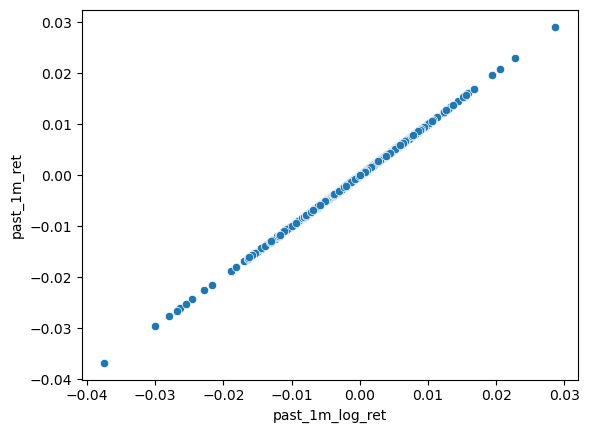

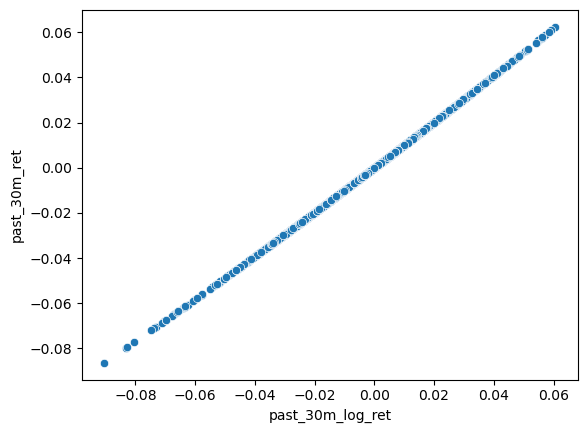

In [6]:
df_train = add_past_returns(df_train, [1, 30], log=False)
df_train = add_past_returns(df_train, [1, 30], log=True)

ax = sns.scatterplot(x=df_train["past_1m_log_ret"], y=df_train["past_1m_ret"])
plt.show()

ax = sns.scatterplot(x=df_train["past_30m_log_ret"], y=df_train["past_30m_ret"])
plt.show()

Okay - we will not use log returns for simplicity.

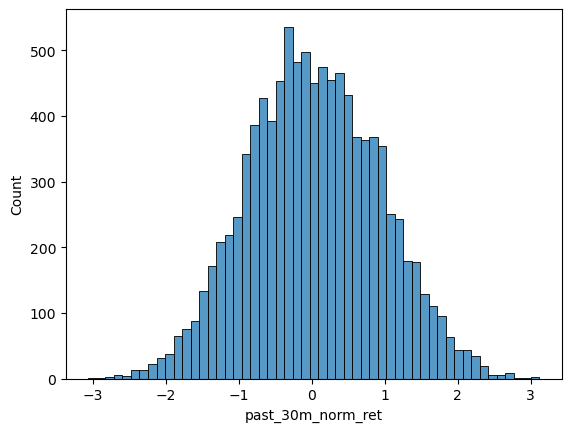

In [7]:
df_train = add_normalized_past_returns(df_train, [30])
ax = sns.histplot(df_train.sample(10000)["past_30m_norm_ret"])

Next step: compare normal vs. t vs. skewed t distribution. Fit parameters on train, then compare performance on val.

In [8]:
import numpy as np
from scipy import stats

df_with_returns = downsample(add_normalized_past_returns(df, [30]).dropna(), set([0, 30]))
z_train = np.asarray(df_with_returns.query("split == 'train'")["past_30m_norm_ret"])
z_val = np.asarray(df_with_returns.query("split == 'val'")["past_30m_norm_ret"])
z_train = np.asarray(z_train)

# Fit distributions
_, scale_norm = stats.norm.fit(z_train, floc=0)

df_t, _, scale_t = stats.t.fit(z_train, floc=0)

a, b, _, scale_s = stats.jf_skew_t.fit(z_train, floc=0)

/opt/homebrew/Caskroom/miniconda/base/envs/final-project/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:5715: RuntimeWarning: overflow encountered in scalar power
  c = 2 ** (a + b - 1) * sc.beta(a, b) * np.sqrt(a + b)
/opt/homebrew/Caskroom/miniconda/base/envs/final-project/lib/python3.10/site-packages/scipy/stats/_continuous_distns.py:5715: RuntimeWarning: invalid value encountered in scalar multiply
  c = 2 ** (a + b - 1) * sc.beta(a, b) * np.sqrt(a + b)


In [9]:
logscore_default_norm = stats.norm.logpdf(
    z_val, loc=0, scale=1
).mean()

logscore_fitted_norm = stats.norm.logpdf(
    z_val, loc=0, scale=scale_norm
).mean()

logscore_t = stats.t.logpdf(
    z_val, df=df_t, loc=0, scale=scale_t
).mean()

logscore_s = stats.jf_skew_t.logpdf(
    z_val, a=a, b=b, loc=0, scale=scale_s
).mean()

print("Log scores\n")
print("Normal unit variance:", logscore_default_norm)
print("Normal fitted variance:", logscore_fitted_norm)
print("t:", logscore_t)
print("Skew-t:", logscore_s)

Log scores

Normal unit variance: -1.3810650767505672
Normal fitted variance: -1.3804724863183568
t: -1.3804724866004794
Skew-t: -1.3805018966429914


In [10]:
def compute_single_crps(F, y, x_grid, dx):
    """
    Compute CRPS for distribution and realization.
    """

    # grid
    left = x_grid <= y
    right = ~left

    crps = (
        np.sum(F[left]**2) * dx +
        np.sum((1 - F[right])**2) * dx
    )

    return crps

def compute_mean_crps(cdf, y_vals, x_min, x_max, n_grid=2000):
    """
    Compute mean crps across a set of realizations.
    """
    x = np.linspace(x_min, x_max, n_grid)
    dx = x[1] - x[0]
    F = cdf(x)
    scores = []
    for y in y_vals:
        scores.append(compute_single_crps(F, y, x, dx))
    return np.mean(scores)


In [ ]:
crps_default_norm = compute_mean_crps(stats.norm.cdf, z_val, -100, 100)
crps_fitted_norm = compute_mean_crps(stats.norm(scale=scale_norm).cdf, z_val, -100, 100)
crps_t = compute_mean_crps(stats.t(df=df_t, scale=scale_t).cdf, z_val, -100, 100)
crps_s = compute_mean_crps(stats.jf_skew_t(a=a, b=b, scale=scale_s).cdf, z_val, -100, 100)

print("CRPS\n")
print("Normal unit:", crps_default_norm)
print("Normal fitted:", crps_fitted_norm)
print("t:", crps_t)
print("Skew-t:", crps_s)

CRPS

Normal unit: 0.5466682371111224
Normal fitted: 0.5470640052023281
t: 0.5470640052732231
Skew-t: 0.5470321813931254


Okay! It looks like we can stick with normal for the two stage model, and potential try a multiplicative constant for scale. As a quick check, let's see what has better PnL if we allow them to trade against each other.

In [12]:
def price_call_normal(sigma: float, strike_return: float, mu: float = 0.0):
    if sigma <= 0:
        return max(mu - strike_return, 0.0)
    z = (mu - strike_return) / sigma
    return (mu - strike_return) * stats.norm.cdf(z) + sigma * stats.norm.pdf(z)

def simulate_call_trades_normal(return_strike, returns, sigmas_one, sigmas_two):
    pnl = []

    for i in range(len(sigmas_one)):
        price_one = price_call_normal(sigmas_one[i], return_strike)
        price_two = price_call_normal(sigmas_two[i], return_strike)
        trade_price = 0.5 * (price_one + price_two)

        payoff = max(returns.iloc[i] - return_strike, 0)

        direction = -1 if price_one < price_two else 1

        pnl.append(direction * (payoff - trade_price))

    return pnl

In [13]:
df = add_past_mean_sq_returns(df, [30])
df_val = downsample(df.query("split == 'val'"), set([0, 30])).dropna()
returns = df_val["past_30m_ret"].reset_index(drop=True)
sigmas_one = np.sqrt(df_val["past_30m_mean_sq_ret"].reset_index(drop=True) * 30)
sigmas_two = np.sqrt(df_val["past_30m_mean_sq_ret"].reset_index(drop=True) * 30) * scale_norm
pnls = simulate_call_trades_normal(0.005, returns, sigmas_one, sigmas_two)

<Axes: >

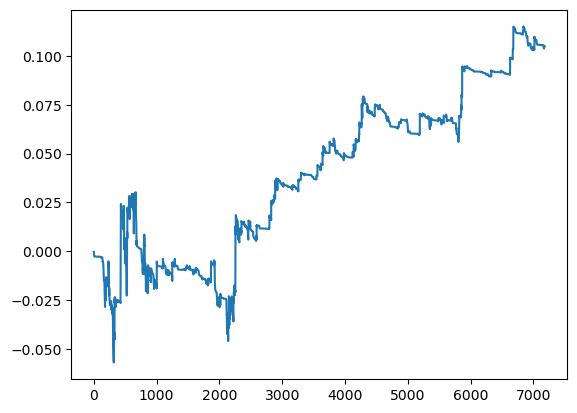

In [14]:
sns.lineplot(np.cumsum(pnls))

Looks about random!

### Part 2: Two-Stage Model
Now we evaluate our two stage model with GBT predictions and a normal distribution, up to some scale.

###

In [47]:
import numpy as np
from scipy.optimize import minimize_scalar

df["future_30m_ret"] = df["past_30m_ret"].shift(-30)

df_train = downsample(df.query("split == 'train'"), set([0, 30])).dropna()
df_val = downsample(df.query("split == 'val'"), set([0, 30])).dropna()

y_train = df_train["future_30m_ret"].reset_index(drop=True)
sigma_train = np.sqrt(df_train["gbt_future_30m_mean_sq_ret_pred"] * 30).reset_index(drop=True)

y_val = df_val["future_30m_ret"].reset_index(drop=True)
sigma_val = np.sqrt(df_val["gbt_future_30m_mean_sq_ret_pred"] * 30).reset_index(drop=True)

def calculate_normal_nll(y, sigma, min_sigma=1e-12):
    """
    Calculate negative log-likelihood from returns and 
    scale parameters.
    """
    sigma = np.clip(sigma, min_sigma, None)
    return np.mean(
        0.5 * np.log(2 * np.pi)
        + np.log(sigma)
        + 0.5 * (y / sigma) ** 2
    )

def objective(c):
    """
    Calculate normal log-likelihood for a multiplicative
    constant * some prediction
    """
    sigma_scaled = np.sqrt(c) * sigma_train
    return calculate_normal_nll(y_train, sigma_scaled)


nll_train_raw = calculate_normal_nll(y_train, sigma_train)
nll_val_raw = calculate_normal_nll(y_val, sigma_val)

c_hat = minimize_scalar(objective, bounds=(0,5), method="bounded").x


sigma_train_const = np.sqrt(c_hat) * sigma_train
sigma_val_const = np.sqrt(c_hat) * sigma_val

nll_train_cal = calculate_normal_nll(y_train, sigma_train_const)
nll_val_cal = calculate_normal_nll(y_val, sigma_val_const)

print(f"Raw two stage NLL neg loglik: {nll_train_raw}")
print(f"Raw two stage val neg loglik: {nll_val_raw}\n")

print(f"Calibrated two stage NLL neg loglik: {nll_train_cal}")
print(f"Calibrated two stage val neg loglik: {nll_val_cal}")

Raw two stage NLL neg loglik: -4.3536277039424
Raw two stage val neg loglik: -4.508380701689935

Calibrated two stage NLL neg loglik: -4.356545926204864
Calibrated two stage val neg loglik: -4.511620763443788


In [48]:
def gaussian_crps(returns, sigma):
    """
    CRPS for N(0, sigma^2) predictions.
    returns : array of realized returns
    sigma   : array of predicted std deviations
    """
    z = returns / sigma
    crps = sigma * (
        z * (2 * stats.norm.cdf(z) - 1)
        + 2 * stats.norm.pdf(z)
        - 1 / np.sqrt(np.pi)
    )
    return np.mean(crps)

crps_raw_val = gaussian_crps(y_val, sigma_val)
crps_const_val = gaussian_crps(y_val, sigma_val_const)

print("CRPS\n")
print("Raw two stage:", crps_raw_val)
print("Calibrated two stage:", crps_const_val)

CRPS

Raw two stage: 0.0016134541799030142
Calibrated two stage: 0.0016174551434874188


<Axes: >

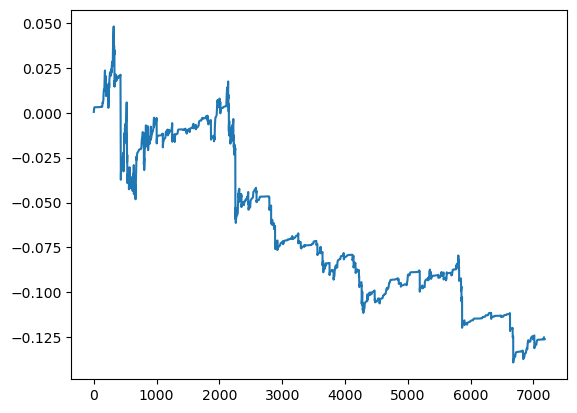

In [49]:
two_stage_pnls = simulate_call_trades_normal(0.005, y_val, sigma_val, sigma_val_const)
sns.lineplot(np.cumsum(two_stage_pnls))